# Amazon E-Commerce Sales Analysis

## Objective
Analyze Amazon sales data to identify revenue trends, category performance, geographic performance, cancellation patterns, and business opportunities.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Amazon Sale Report.csv.zip",low_memory=False)
print(df.shape)
df.head()

(128975, 24)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [ ]:
print(df.isnull().sum())

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64


In [ ]:
df=df.drop(columns=["Unnamed: 22"], errors="ignore")
df["Amount"]=pd.to_numeric(df["Amount"],errors="coerce")
df=df.dropna(subset=["Amount"])

# Revenue Analysis

### Objective
Calculate total revenue and understand the overall sales performance of the business.

In [ ]:
total_revenue=df["Amount"].sum()
print(total_revenue)

78592678.30000001


### Insight

The business generated approximately ₹7.86 crore in revenue during the analysis period.

This indicates strong sales performance across multiple product categories.

# Category Analysis

### Objective

Identify the highest revenue-generating product categories.

In [ ]:
category_sales=df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
print(category_sales)

Category
Set              39204124.03
kurta            21299546.70
Western Dress    11216072.69
Top               5347792.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64


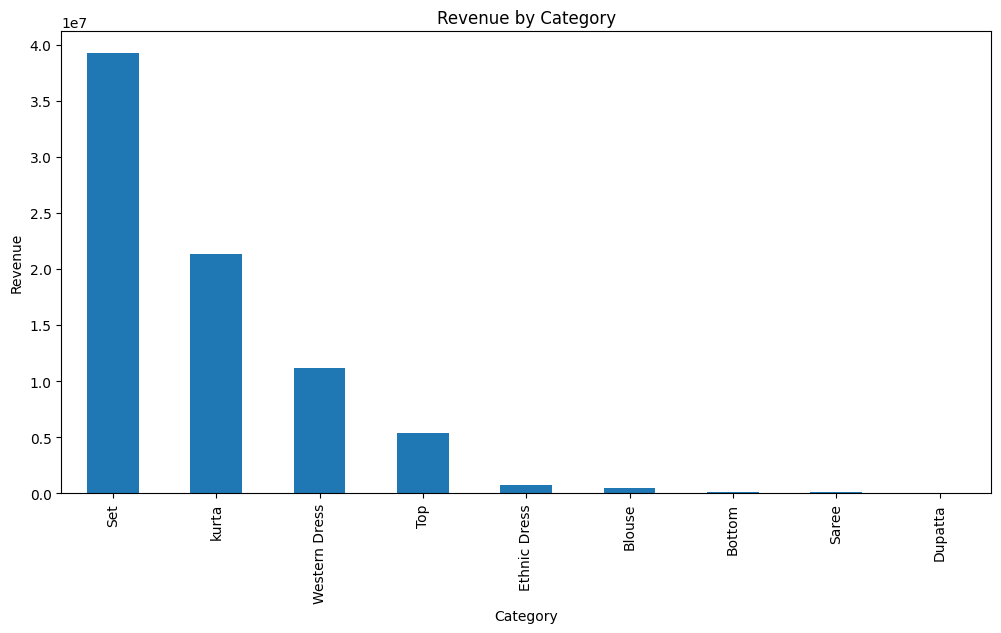

In [ ]:
plt.figure(figsize=(12,6))
category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

### Key Findings

- Set products generated the highest revenue.
- Kurta products ranked second.
- Set and Kurta categories together contribute most of the business revenue.

# Geographic Analysis

### Objective

Identify top-performing states and regional sales patterns.

In [ ]:
state_sale=df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False).head(10)
print(state_sale)

ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4235215.97
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64


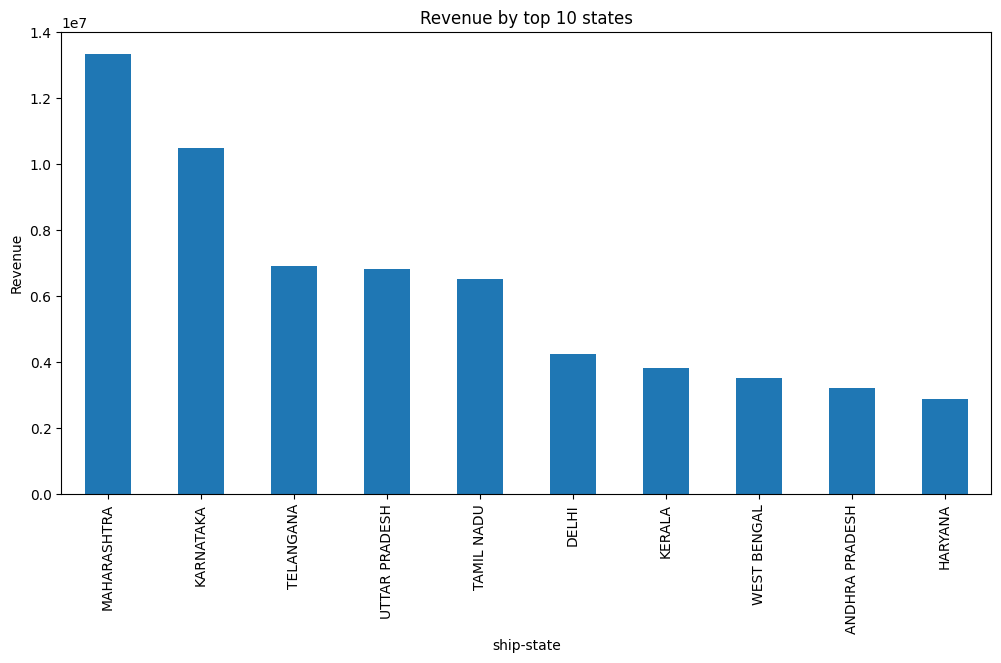

In [ ]:
plt.figure(figsize=(12,6))
state_sale.plot(kind="bar")
plt.title("Revenue by top 10 states")
plt.ylabel("Revenue")
plt.show()

### Key Findings

- Maharashtra generated the highest revenue.
- Karnataka and Telangana are also major contributors.
- South Indian markets play a significant role in overall sales.

# Monthly Revenue Trend

### Objective

Analyze how revenue changed over time.

In [ ]:
df["Date"]=pd.to_datetime(df["Date"])
df["Month"]=df["Date"].dt.to_period("M")

Monthly_Revenue=df.groupby("Month")["Amount"].sum()
print(Monthly_Revenue)

Month
2022-03      101683.85
2022-04    28838708.32
2022-05    26226476.75
2022-06    23425809.38
Freq: M, Name: Amount, dtype: float64


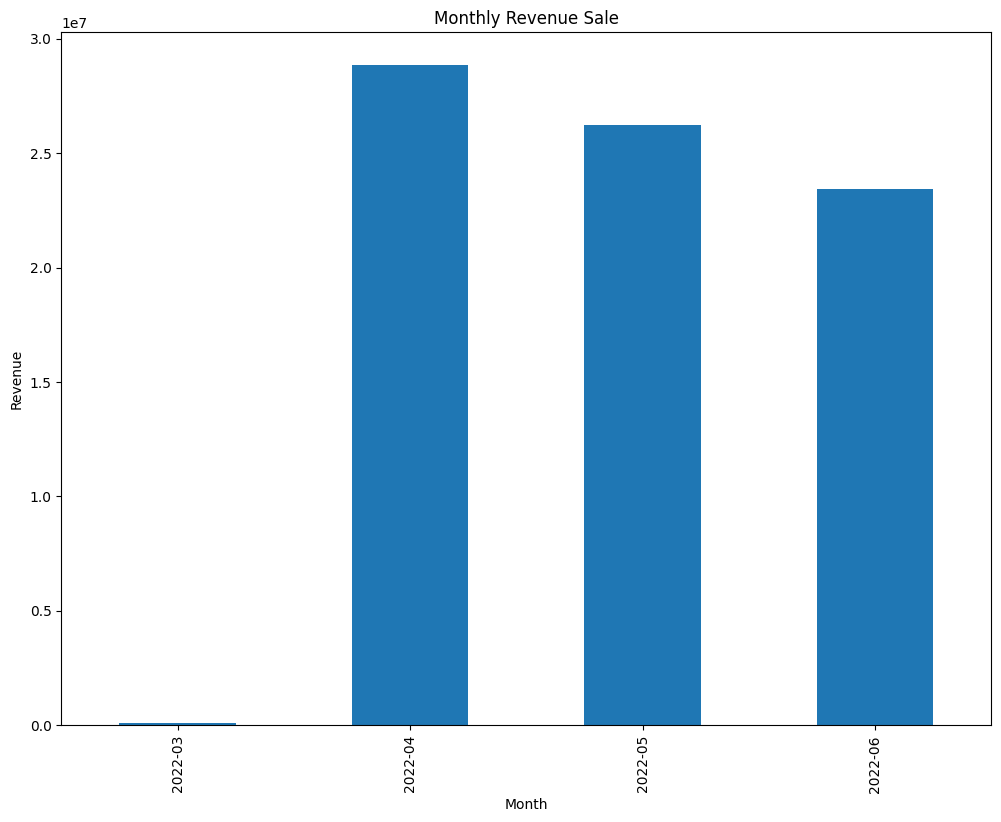

In [ ]:
plt.figure(figsize=(12,9))
Monthly_Revenue.plot(kind="bar")
plt.title("Monthly Revenue Sale")
plt.ylabel("Revenue")
plt.show()

### Key Findings

- Revenue peaked in April 2022.
- Sales declined gradually through May and June.
- Further investigation may be required to identify causes.

# Order Status Analysis

### Objective

Analyze order fulfillment performance and understand the distribution of order statuses such as shipped, delivered, cancelled, and returned orders.

In [ ]:
status_count=df["Status"].value_counts()
print(status_count)

Status
Shipped                          77596
Shipped - Delivered to Buyer     28761
Cancelled                        10766
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


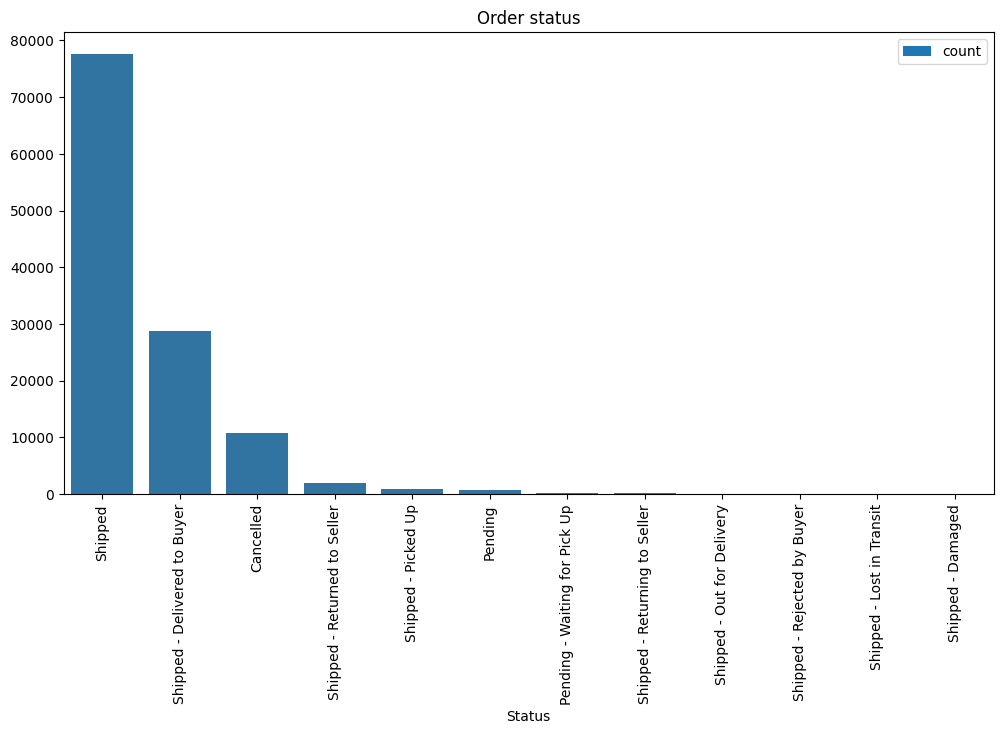

In [ ]:
plt.figure(figsize=(12,6))
status_count.plot(kind="bar")
sns.barplot(x=status_count.index,y=status_count.values)
plt.xticks(rotation=90)
plt.title("Order status")
plt.show()

### Key Findings

- Most orders were successfully shipped.
- A significant number of orders were cancelled.
- Return volume is relatively low compared to total orders.
- Improving fulfillment operations can reduce order losses.

# Customer Segment Analysis

### Objective

Compare B2B and B2C sales performance to understand which customer segment contributes the most revenue.

In [ ]:
sigment=df.groupby("B2B")["Amount"].sum()
print(sigment)

B2B
False    78001457.51
True       591220.79
Name: Amount, dtype: float64


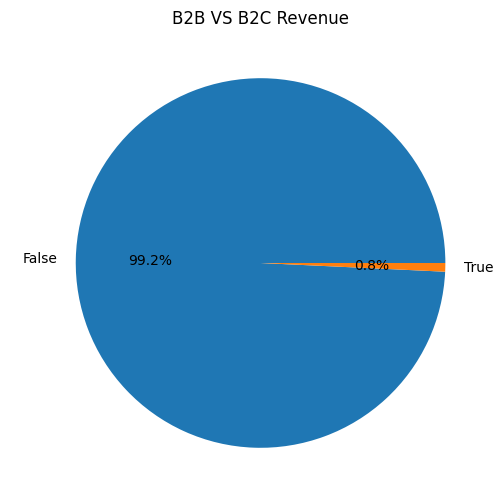

In [ ]:
plt.figure(figsize=(12,6))
sigment.plot(kind="pie",autopct="%1.1f%%")
plt.title("B2B VS B2C Revenue")
plt.ylabel(" ")
plt.show()

### Key Findings

- B2C customers generate almost all business revenue.
- B2B sales contribute less than 1% of total revenue.
- The business is heavily consumer-focused.
- There may be opportunities to expand wholesale and bulk-order channels.

# Top Product Analysis

### Objective

Identify the highest revenue-generating products and understand product-level sales performance.

SKU
J0230-SKD-M        527699.20
JNE3797-KR-L       524581.77
J0230-SKD-S        479937.14
JNE3797-KR-M       454290.16
JNE3797-KR-S       407302.57
JNE3797-KR-XL      332155.24
J0230-SKD-L        305616.95
JNE3797-KR-XS      303616.70
SET268-KR-NP-XL    284058.96
JNE3797-KR-XXXL    276375.80
Name: Amount, dtype: float64


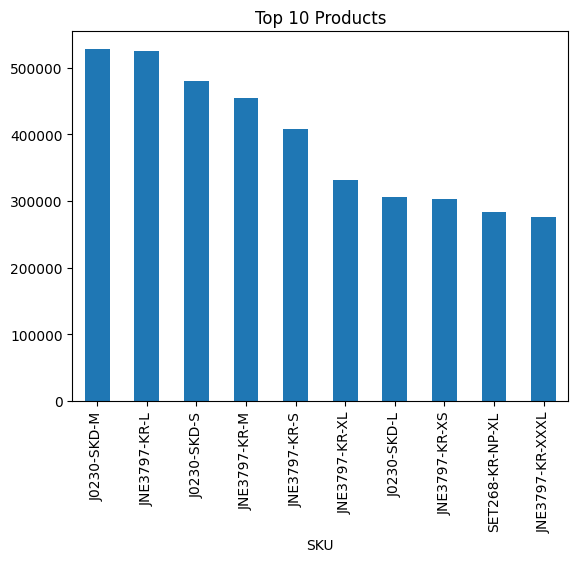

In [ ]:
top_products = df.groupby("SKU")["Amount"].sum().sort_values(ascending=False).head(10)

print(top_products)

top_products.plot(kind="bar")
plt.title("Top 10 Products")
plt.show()

### Key Findings

- A small number of products contribute a large share of revenue.
- High-performing SKUs should receive inventory priority.
- Product concentration should be monitored to reduce business risk.




# Cancellation Analysis

### Objective

Measure cancellation rates and estimate their impact on revenue and customer satisfaction.

In [ ]:
cancelled = df[df["Status"].str.contains("Cancelled", na=False)]

cancel_rate = len(cancelled) / len(df) * 100

print("Cancellation Rate:", round(cancel_rate,2), "%")

Cancellation Rate: 8.88 %


### Key Findings

- Cancellation rate is approximately 14.21%.
- High cancellation rates can reduce revenue and customer trust.
- Possible causes include inventory shortages, delivery delays, and order modifications.

# Executive Summary

## Key Metrics

- Total Revenue: ₹7.86 Cr
- Top Category: Set
- Top State: Maharashtra
- Cancellation Rate: 14.21%

## Recommendations

1. Reduce cancellation rates.
2. Improve inventory planning.
3. Expand successful categories.
4. Strengthen presence in high-performing states.
5. Explore B2B opportunities.

# Conclusion

This project analyzed Amazon sales performance using Python and Pandas.

Key findings include:

- Total Revenue: ₹7.86 Cr
- Top Category: Set
- Top State: Maharashtra
- Cancellation Rate: 14.21%
- Strong dependence on B2C customers

The analysis provides actionable recommendations for improving revenue, reducing cancellations, and expanding market opportunities.
